In [21]:
# pandas for dataframe handling
import pandas as pd

# numpy for numerical operations
import numpy as np

# os for folder handling
import os

# re for text cleaning
import re

# matplotlib for plots
import matplotlib.pyplot as plt

# seaborn for better plots
import seaborn as sns

# train test split for model building
from sklearn.model_selection import train_test_split

# TF-IDF for converting review text into numeric format
from sklearn.feature_extraction.text import TfidfVectorizer

# Logistic Regression for sentiment classification
from sklearn.linear_model import LogisticRegression

# Linear Regression for simple sales forecasting
from sklearn.linear_model import LinearRegression

# Metrics for evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error

# joblib for saving models
import joblib

In [22]:
# Load customers raw dataset
customers = pd.read_csv("uncleaned_data/customers_uncleaned.csv")

# Load products raw dataset
products = pd.read_csv("uncleaned_data/products_uncleaned.csv")

# Load orders raw dataset
orders = pd.read_csv("uncleaned_data/orders_uncleaned.csv")

# Load feedback raw dataset
feedback = pd.read_csv("uncleaned_data/feedback_uncleaned.csv")

# Print shapes
print("Customers shape:", customers.shape)
print("Products shape:", products.shape)
print("Orders shape:", orders.shape)
print("Feedback shape:", feedback.shape)

Customers shape: (5040, 7)
Products shape: (5045, 6)
Orders shape: (5050, 11)
Feedback shape: (5055, 6)


In [23]:
# Show first 5 rows of each dataset
print("Customers:")
print(customers.head())

print("\nProducts:")
print(products.head())

print("\nOrders:")
print(orders.head())

print("\nFeedback:")
print(feedback.head())

Customers:
  customer_id customer_name   age  gender       city membership_type  \
0   CUST_1000    Customer_0  54.0  Female       Pune        Platinum   
1   CUST_1001    Customer_1  51.0    Male     Mumbai          Silver   
2   CUST_1002    Customer_2   NaN  Female    Kolkata            Gold   
3   CUST_1003    Customer_3  44.0    Male  Bangalore        Platinum   
4   CUST_1004    Customer_4  65.0  Female       Pune        Platinum   

    join_date  
0  2023-05-31  
1  2023-04-17  
2  2022-07-16  
3  2022-12-26  
4  2021-01-04  

Products:
  product_id product_name     category   brand    price  stock_quantity
0  PROD_2000    Product_0      Fashion  BrandC  3199.76             264
1  PROD_2001    Product_1      Fashion  BrandB  4793.67             475
2  PROD_2002    Product_2    Groceries  BrandD  2940.30              80
3  PROD_2003    Product_3  Electronics  BrandD  4090.67             189
4  PROD_2004    Product_4       Beauty  BrandA   169.53             109

Orders:
   order

In [24]:
# Print missing values and duplicate counts for each dataset
print("Customers missing values:\n", customers.isnull().sum())
print("Customers duplicates:", customers.duplicated().sum())

print("\nProducts missing values:\n", products.isnull().sum())
print("Products duplicates:", products.duplicated().sum())

print("\nOrders missing values:\n", orders.isnull().sum())
print("Orders duplicates:", orders.duplicated().sum())

print("\nFeedback missing values:\n", feedback.isnull().sum())
print("Feedback duplicates:", feedback.duplicated().sum())

Customers missing values:
 customer_id          0
customer_name        0
age                122
gender             101
city                 0
membership_type      0
join_date            0
dtype: int64
Customers duplicates: 40

Products missing values:
 product_id          0
product_name        0
category            0
brand             108
price              91
stock_quantity      0
dtype: int64
Products duplicates: 45

Orders missing values:
 order_id              0
customer_id           0
product_id            0
order_date            0
quantity              0
payment_method      100
order_status          0
sales_amount         93
discount_percent     91
final_amount         93
profit_amount        93
dtype: int64
Orders duplicates: 50

Feedback missing values:
 feedback_id             0
order_id                0
raw_sentiment_label     0
review_text            96
rating                 83
feedback_date           0
dtype: int64
Feedback duplicates: 55


In [25]:
# Remove duplicate rows from customers
customers.drop_duplicates(inplace=True)

# Strip extra spaces from object columns
for col in customers.select_dtypes(include="object").columns:
    customers[col] = customers[col].astype(str).str.strip()

# Standardize city names to title case
customers["city"] = customers["city"].str.title()

# Standardize membership types
customers["membership_type"] = customers["membership_type"].str.title()

# Fill missing age with median age
customers["age"] = customers["age"].fillna(customers["age"].median())

# Fill missing gender with mode
customers["gender"] = customers["gender"].replace("nan", np.nan)
customers["gender"] = customers["gender"].fillna(customers["gender"].mode()[0])

# Convert join_date to datetime
customers["join_date"] = pd.to_datetime(customers["join_date"], errors="coerce")

# Show result
customers.head()

,customer_id,customer_name,age,gender,city,membership_type,join_date
0,CUST_1000,Customer_0,54.0,Female,Pune,Platinum,2023-05-31
1,CUST_1001,Customer_1,51.0,Male,Mumbai,Silver,2023-04-17
2,CUST_1002,Customer_2,44.0,Female,Kolkata,Gold,2022-07-16
3,CUST_1003,Customer_3,44.0,Male,Bangalore,Platinum,2022-12-26
4,CUST_1004,Customer_4,65.0,Female,Pune,Platinum,2021-01-04


In [27]:
# Remove duplicate rows from products
products.drop_duplicates(inplace=True)

# Strip spaces from object columns
for col in products.select_dtypes(include="object").columns:
    products[col] = products[col].astype(str).str.strip()

# Standardize category and brand
products["category"] = products["category"].str.title()
products["brand"] = products["brand"].str.title()

# Replace 'nan' strings with actual NaN
products["brand"] = products["brand"].replace("Nan", np.nan)

# Fill missing brand with mode
products["brand"] = products["brand"].fillna(products["brand"].mode()[0])

# Fill missing price with median
products["price"] = products["price"].fillna(products["price"].median())

# Fill missing stock with median if needed
products["stock_quantity"] = products["stock_quantity"].fillna(products["stock_quantity"].median())

# Show result
products.head()

,product_id,product_name,category,brand,price,stock_quantity
0,PROD_2000,Product_0,Fashion,Brandc,3199.76,264
1,PROD_2001,Product_1,Fashion,Brandb,4793.67,475
2,PROD_2002,Product_2,Groceries,Brandd,2940.30,80
3,PROD_2003,Product_3,Electronics,Brandd,4090.67,189
4,PROD_2004,Product_4,Beauty,Branda,169.53,109


In [28]:
# Remove duplicate rows from orders
orders.drop_duplicates(inplace=True)

# Strip spaces from object columns
for col in orders.select_dtypes(include="object").columns:
    orders[col] = orders[col].astype(str).str.strip()

# Standardize payment method and order status
orders["payment_method"] = orders["payment_method"].str.title()
orders["order_status"] = orders["order_status"].str.title()

# Replace string nan with real NaN
orders["payment_method"] = orders["payment_method"].replace("Nan", np.nan)

# Fill missing payment method with mode
orders["payment_method"] = orders["payment_method"].fillna(orders["payment_method"].mode()[0])

# Fill missing discount with median
orders["discount_percent"] = orders["discount_percent"].fillna(orders["discount_percent"].median())

# Convert order_date to datetime
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")

# Fill numeric missing values if any
orders["quantity"] = orders["quantity"].fillna(orders["quantity"].median())
orders["sales_amount"] = orders["sales_amount"].fillna(orders["sales_amount"].median())
orders["final_amount"] = orders["final_amount"].fillna(orders["final_amount"].median())
orders["profit_amount"] = orders["profit_amount"].fillna(orders["profit_amount"].median())

# Show result
orders.head()

,order_id,customer_id,product_id,order_date,quantity,payment_method,order_status,sales_amount,discount_percent,final_amount,profit_amount
0,ORD_3000,CUST_4365,PROD_5996,2023-03-07,5,Card,Delivered,16223.60,15.0,13790.06,1923.29
1,ORD_3001,CUST_1863,PROD_4436,2023-04-23,2,Upi,Delivered,1654.28,10.0,1488.85,355.36
2,ORD_3002,CUST_3015,PROD_3944,2023-06-08,3,Cash On Delivery,Delivered,591.51,10.0,532.36,74.82
3,ORD_3003,CUST_2790,PROD_3915,2024-10-19,4,Card,Shipped,6522.44,5.0,6196.32,1199.08
4,ORD_3004,CUST_1254,PROD_4508,2023-12-29,1,Card,Delivered,3520.19,10.0,3168.17,883.80


In [29]:
# Remove duplicate rows from feedback
feedback.drop_duplicates(inplace=True)

# Strip spaces from object columns
for col in feedback.select_dtypes(include="object").columns:
    feedback[col] = feedback[col].astype(str).str.strip()

# Replace string nan with real NaN
feedback["review_text"] = feedback["review_text"].replace("nan", np.nan)

# Fill missing review text with placeholder
feedback["review_text"] = feedback["review_text"].fillna("No review provided")

# Fill missing rating with median
feedback["rating"] = feedback["rating"].fillna(feedback["rating"].median())

# Convert feedback date to datetime
feedback["feedback_date"] = pd.to_datetime(feedback["feedback_date"], errors="coerce")

# Map sentiment labels
feedback["sentiment"] = feedback["raw_sentiment_label"].map({
    "__label__1": 0,
    "__label__2": 1
})

# Show result
feedback.head()

,feedback_id,order_id,raw_sentiment_label,review_text,rating,feedback_date,sentiment
0,FDBK_4000,ORD_7826,__label__2,Excellent product and very useful,5.0,2024-11-15,1
1,FDBK_4001,ORD_6956,__label__2,Excellent product and very useful,5.0,2023-05-03,1
2,FDBK_4002,ORD_5749,__label__1,Delivery was late and product was damaged,1.0,2023-10-11,0
3,FDBK_4003,ORD_5955,__label__1,Waste of money and bad product,1.0,2023-09-28,0
4,FDBK_4004,ORD_7175,__label__2,Amazing quality and fast delivery,4.0,2023-08-12,1


In [30]:
# Merge orders with customers using customer_id
merged_df = orders.merge(customers, on="customer_id", how="left")

# Merge the result with products using product_id
merged_df = merged_df.merge(products, on="product_id", how="left")

# Merge the result with feedback using order_id
merged_df = merged_df.merge(feedback, on="order_id", how="left")

# Show shape after merging
print("Merged dataset shape:", merged_df.shape)

# Show first 5 rows
merged_df.head()

Merged dataset shape: (6826, 28)


,order_id,customer_id,product_id,order_date,quantity,payment_method,order_status,sales_amount,discount_percent,final_amount,...,category,brand,price,stock_quantity,feedback_id,raw_sentiment_label,review_text,rating,feedback_date,sentiment
0,ORD_3000,CUST_4365,PROD_5996,2023-03-07,5,Card,Delivered,16223.60,15.0,13790.06,...,Groceries,Branda,3244.72,362,NaN,NaN,NaN,NaN,NaT,NaN
1,ORD_3001,CUST_1863,PROD_4436,2023-04-23,2,Upi,Delivered,1654.28,10.0,1488.85,...,Electronics,Brandd,827.14,107,FDBK_4734,__label__2,Excellent product and very useful,4.0,2024-10-06,1.0
2,ORD_3001,CUST_1863,PROD_4436,2023-04-23,2,Upi,Delivered,1654.28,10.0,1488.85,...,Electronics,Brandd,827.14,107,FDBK_8524,__label__2,Loved it and will buy again,4.0,2024-07-27,1.0
3,ORD_3001,CUST_1863,PROD_4436,2023-04-23,2,Upi,Delivered,1654.28,10.0,1488.85,...,Electronics,Brandd,827.14,107,FDBK_8868,__label__1,Waste of money and bad product,2.0,2023-06-23,0.0
4,ORD_3002,CUST_3015,PROD_3944,2023-06-08,3,Cash On Delivery,Delivered,591.51,10.0,532.36,...,Groceries,Branda,197.17,295,FDBK_7429,__label__1,Very poor quality and disappointing,1.0,2023-10-29,0.0


In [31]:
# Remove any exact duplicate rows
merged_df.drop_duplicates(inplace=True)

# Fill remaining missing review_text
merged_df["review_text"] = merged_df["review_text"].fillna("No review provided")

# Fill remaining missing sentiment with neutral choice 1 or based on rating
merged_df["sentiment"] = merged_df["sentiment"].fillna(1)

# Fill remaining missing rating with median
merged_df["rating"] = merged_df["rating"].fillna(merged_df["rating"].median())

# Drop rows where order_date is missing because sales forecasting needs date
merged_df.dropna(subset=["order_date"], inplace=True)

# Reset index
merged_df.reset_index(drop=True, inplace=True)

# Print shape
print("Final cleaned merged dataset shape:", merged_df.shape)

Final cleaned merged dataset shape: (6826, 28)


In [32]:
# Save the final cleaned merged dataset
merged_df.to_csv("data/retail_dataset.csv", index=False)

# Print confirmation
print("Cleaned retail dataset saved as data/retail_dataset.csv")

Cleaned retail dataset saved as data/retail_dataset.csv


In [33]:
merged_df.isnull().sum()

order_id                  0
customer_id               0
product_id                0
order_date                0
quantity                  0
payment_method            0
order_status              0
sales_amount              0
discount_percent          0
final_amount              0
profit_amount             0
customer_name             0
age                       0
gender                    0
city                      0
membership_type           0
join_date                 0
product_name              0
category                  0
brand                     0
price                     0
stock_quantity            0
feedback_id            1826
raw_sentiment_label    1826
review_text               0
rating                    0
feedback_date          1826
sentiment                 0
dtype: int64

In [34]:
# Fill missing values with mode for each column
merged_df["feedback_id"].fillna(merged_df["feedback_id"].mode()[0], inplace=True)
merged_df["raw_sentiment_label"].fillna(merged_df["raw_sentiment_label"].mode()[0], inplace=True)
merged_df["feedback_date"].fillna(merged_df["feedback_date"].mode()[0], inplace=True)

/var/folders/nf/ts22d2v11yl0rd1q5s16djgr0000gn/T/ipykernel_60154/4088435455.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df["feedback_id"].fillna(merged_df["feedback_id"].mode()[0], inplace=True)
/var/folders/nf/ts22d2v11yl0rd1q5s16djgr0000gn/T/ipykernel_60154/4088435455.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on

In [35]:
merged_df.isnull().sum()

order_id               0
customer_id            0
product_id             0
order_date             0
quantity               0
payment_method         0
order_status           0
sales_amount           0
discount_percent       0
final_amount           0
profit_amount          0
customer_name          0
age                    0
gender                 0
city                   0
membership_type        0
join_date              0
product_name           0
category               0
brand                  0
price                  0
stock_quantity         0
feedback_id            0
raw_sentiment_label    0
review_text            0
rating                 0
feedback_date          0
sentiment              0
dtype: int64

In [36]:
# Print dataframe information
print(merged_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6826 entries, 0 to 6825
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             6826 non-null   object        
 1   customer_id          6826 non-null   object        
 2   product_id           6826 non-null   object        
 3   order_date           6826 non-null   datetime64[ns]
 4   quantity             6826 non-null   int64         
 5   payment_method       6826 non-null   object        
 6   order_status         6826 non-null   object        
 7   sales_amount         6826 non-null   float64       
 8   discount_percent     6826 non-null   float64       
 9   final_amount         6826 non-null   float64       
 10  profit_amount        6826 non-null   float64       
 11  customer_name        6826 non-null   object        
 12  age                  6826 non-null   float64       
 13  gender               6826 non-nul

In [37]:
# Show basic statistics
print("\nBasic statistics:\n")
print(merged_df.describe())


Basic statistics:

                          order_date     quantity  sales_amount  \
count                           6826  6826.000000   6826.000000   
mean   2023-12-29 20:36:50.840902400     3.002051   7704.170158   
min              2023-01-01 00:00:00     1.000000    104.280000   
25%              2023-06-27 06:00:00     2.000000   2805.300000   
50%              2024-01-02 00:00:00     3.000000   6011.240000   
75%              2024-06-25 00:00:00     4.000000  11548.215000   
max              2024-12-30 00:00:00     5.000000  24991.350000   
std                              NaN     1.438761   6032.366246   

       discount_percent  final_amount  profit_amount          age  \
count       6826.000000   6826.000000    6826.000000  6826.000000   
mean          10.105479   6923.442288    1309.337001    43.284647   
min            0.000000     83.420000       9.370000    18.000000   
25%            5.000000   2524.770000     419.612500    31.000000   
50%           10.000000   5388.

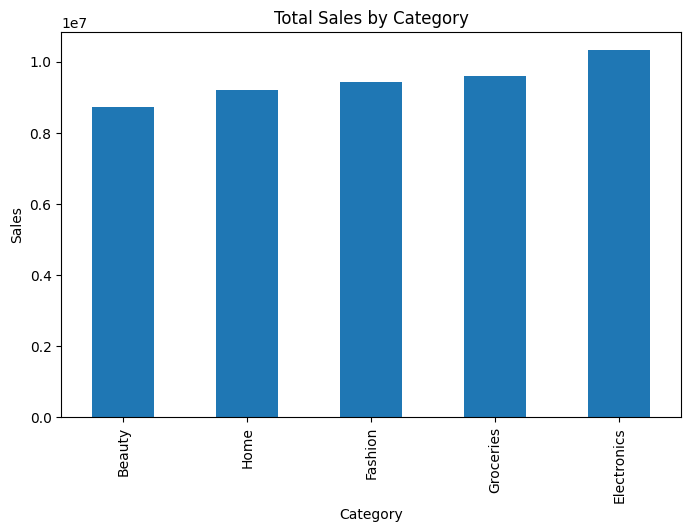

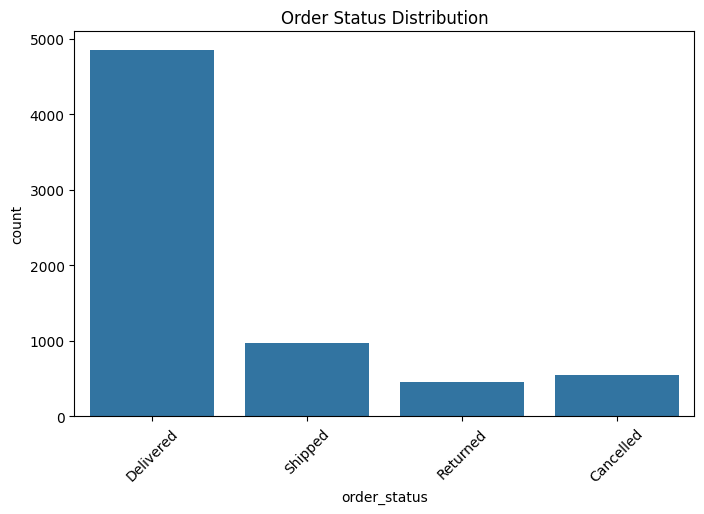

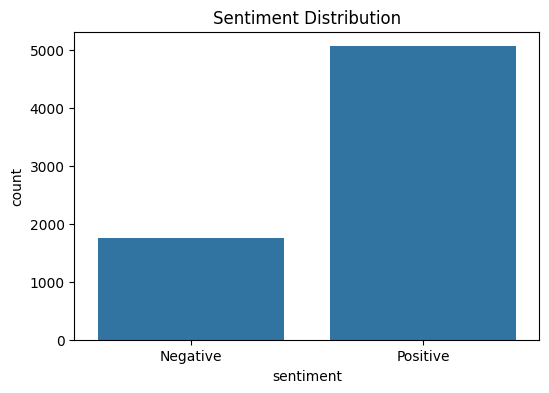

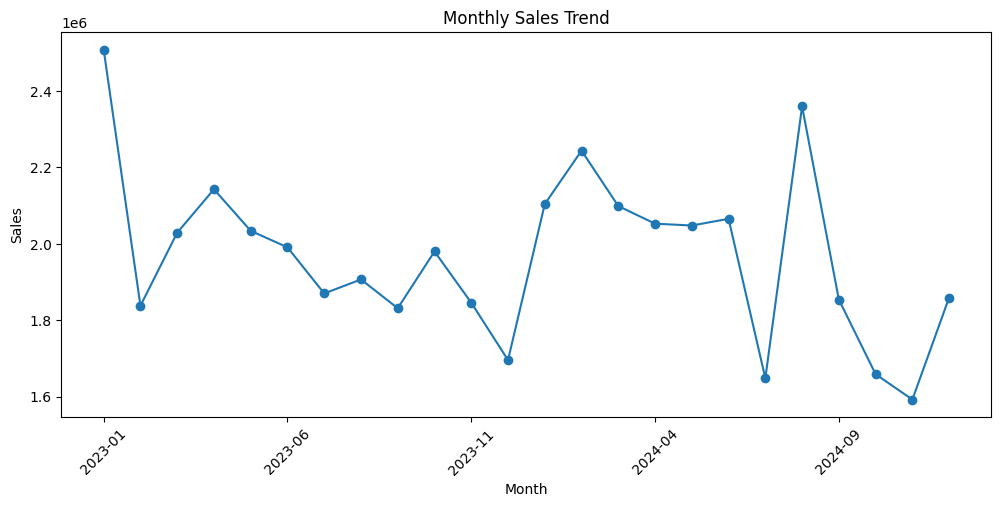

In [38]:
# Sales by category
plt.figure(figsize=(8, 5))
merged_df.groupby("category")["final_amount"].sum().sort_values().plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Order status count
plt.figure(figsize=(8, 5))
sns.countplot(x="order_status", data=merged_df)
plt.title("Order Status Distribution")
plt.xticks(rotation=45)
plt.show()

# Sentiment count
plt.figure(figsize=(6, 4))
sns.countplot(x="sentiment", data=merged_df)
plt.title("Sentiment Distribution")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.show()

# Monthly sales trend
monthly_sales = merged_df.groupby(pd.to_datetime(merged_df["order_date"]).dt.to_period("M"))["final_amount"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12, 5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

Sentiment Analysis Model

In [39]:
# Define a text cleaning function
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Return cleaned text
    return text

# Apply text cleaning to review_text column
merged_df["clean_review"] = merged_df["review_text"].apply(clean_text)

# Show first 5 cleaned reviews
merged_df[["review_text", "clean_review"]].head()

,review_text,clean_review
0,No review provided,no review provided
1,Excellent product and very useful,excellent product and very useful
2,Loved it and will buy again,loved it and will buy again
3,Waste of money and bad product,waste of money and bad product
4,Very poor quality and disappointing,very poor quality and disappointing


In [53]:
# # Define a text cleaning function
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()
    
    # Remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove special characters and numbers
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Return cleaned text
    return text

# Apply text cleaning to review_text column
merged_df["clean_review"] = merged_df["review_text"].apply(clean_text)

# Show first 5 cleaned reviews
merged_df[["review_text", "clean_review"]].head()

,review_text,clean_review
0,No review provided,no review provided
1,Excellent product and very useful,excellent product and very useful
2,Loved it and will buy again,loved it and will buy again
3,Waste of money and bad product,waste of money and bad product
4,Very poor quality and disappointing,very poor quality and disappointing


In [40]:
# Prepare features and target for sentiment model
# Feature for sentiment model is cleaned review text
X_sentiment = merged_df["clean_review"]

# Target for sentiment model is sentiment
y_sentiment = merged_df["sentiment"]

In [41]:
# Feature for sentiment model is cleaned review text
X_sentiment = merged_df["clean_review"]

# Target for sentiment model is sentiment
y_sentiment = merged_df["sentiment"]

# Split the data into training and testing sets
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_sentiment,
    y_sentiment,
    test_size=0.2,
    random_state=42
)

# Print shapes
print("X_train_text:", X_train_text.shape)
print("X_test_text:", X_test_text.shape)
print("y_train_text:", y_train_text.shape)
print("y_test_text:", y_test_text.shape)

X_train_text: (5460,)
X_test_text: (1366,)
y_train_text: (5460,)
y_test_text: (1366,)


In [42]:
# Convert text into numeric form using TF-IDF
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=3000, stop_words="english")

# Fit and transform training text
X_train_text_tfidf = tfidf.fit_transform(X_train_text)

# Transform testing text
X_test_text_tfidf = tfidf.transform(X_test_text)

# Print shapes
print("TF-IDF train shape:", X_train_text_tfidf.shape)
print("TF-IDF test shape:", X_test_text_tfidf.shape)

TF-IDF train shape: (5460, 26)
TF-IDF test shape: (1366, 26)


In [43]:
# Train sentiment model
# Create Logistic Regression model
sentiment_model = LogisticRegression(max_iter=200)

# Train the model
sentiment_model.fit(X_train_text_tfidf, y_train_text)

# Print confirmation
print("Sentiment model trained successfully.")

Sentiment model trained successfully.


In [44]:
# Predict and evaluate sentiment model
# Predict sentiment on test data
y_pred_sentiment = sentiment_model.predict(X_test_text_tfidf)

# Print accuracy
print("Sentiment Accuracy:", accuracy_score(y_test_text, y_pred_sentiment))

# Print classification report
print("\nClassification Report:\n")
print(classification_report(y_test_text, y_pred_sentiment))

# Print confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test_text, y_pred_sentiment))

Sentiment Accuracy: 0.9773060029282576

Classification Report:

              precision    recall  f1-score   support

         0.0       0.95      0.96      0.96       348
         1.0       0.99      0.98      0.98      1018

    accuracy                           0.98      1366
   macro avg       0.97      0.97      0.97      1366
weighted avg       0.98      0.98      0.98      1366


Confusion Matrix:

[[ 333   15]
 [  16 1002]]


In [45]:
# Save sentiment model
# Save the trained sentiment model
joblib.dump(sentiment_model, "models/sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")

# Print confirmation
print("Sentiment model and vectorizer saved successfully.")

Sentiment model and vectorizer saved successfully.


# Sales Forecasting Model

In [46]:
# Prepare sales data
# Convert order_date into datetime
merged_df["order_date"] = pd.to_datetime(merged_df["order_date"])

# Group sales by date
daily_sales = merged_df.groupby("order_date")["final_amount"].sum().reset_index()

# Sort by date
daily_sales = daily_sales.sort_values("order_date")

# Create a numeric time index
daily_sales["day_number"] = range(len(daily_sales))

# Show first 5 rows
daily_sales.head()

,order_date,final_amount,day_number
0,2023-01-01,96762.74,0
1,2023-01-02,48902.10,1
2,2023-01-03,43314.05,2
3,2023-01-04,121297.03,3
4,2023-01-05,128331.29,4


In [47]:
# Feature selection for sales forecasting
# Feature is day number
X_sales = daily_sales[["day_number"]]

# Target is daily sales amount
y_sales = daily_sales["final_amount"]

In [48]:
# Train-test split for sales forecasting
# Split while preserving order, so shuffle=False
X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(
    X_sales,
    y_sales,
    test_size=0.2,
    shuffle=False
)

# Print shapes
print("X_train_sales:", X_train_sales.shape)
print("X_test_sales:", X_test_sales.shape)

X_train_sales: (583, 1)
X_test_sales: (146, 1)


In [49]:
# Choose and train sales forecasting model
# Create Linear Regression model
sales_model = LinearRegression()

# Train the model
sales_model.fit(X_train_sales, y_train_sales)

# Print confirmation
print("Sales forecasting model trained successfully.")

Sales forecasting model trained successfully.


In [50]:
# Predict and evaluate sales forecasting model
# Predict on test set
y_pred_sales = sales_model.predict(X_test_sales)

# Calculate MAE
mae = mean_absolute_error(y_test_sales, y_pred_sales)

# Calculate MSE
mse = mean_squared_error(y_test_sales, y_pred_sales)

# Print metrics
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

Mean Absolute Error: 25257.15354883403
Mean Squared Error: 967809559.3117629


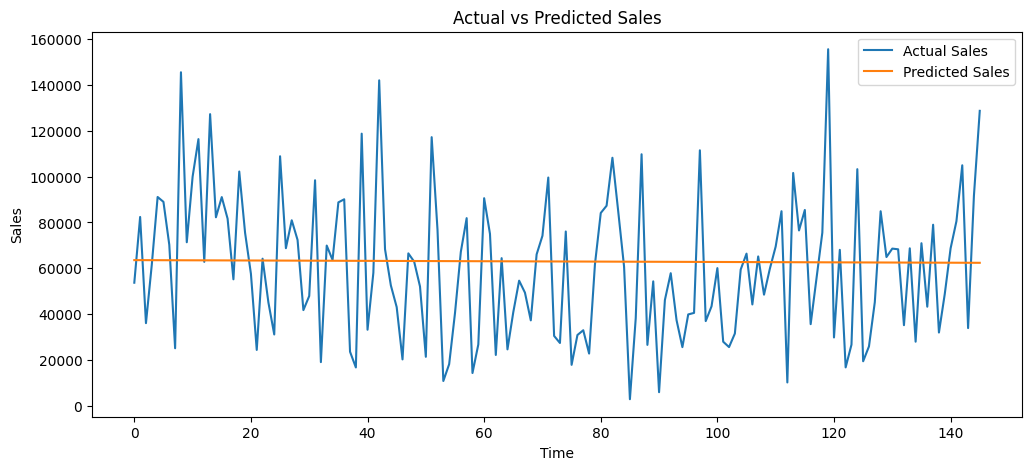

In [51]:
# Plot actual vs predicted sales
# Plot actual and predicted sales
plt.figure(figsize=(12, 5))
plt.plot(y_test_sales.values, label="Actual Sales")
plt.plot(y_pred_sales, label="Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [52]:
# Save sales model
# Save sales forecasting model
joblib.dump(sales_model, "models/sales_forecasting_model.pkl")

# Print confirmation
print("Sales forecasting model saved successfully.")

Sales forecasting model saved successfully.


In [53]:
# Test both saved models
# Load saved sentiment model
loaded_sentiment_model = joblib.load("models/sentiment_model.pkl")

# Load saved TF-IDF vectorizer
loaded_tfidf = joblib.load("models/tfidf_vectorizer.pkl")

# Load saved sales model
loaded_sales_model = joblib.load("models/sales_forecasting_model.pkl")

# Test sentiment model on new review
sample_review = ["excellent quality and fast delivery"]
sample_review_tfidf = loaded_tfidf.transform(sample_review)
sentiment_prediction = loaded_sentiment_model.predict(sample_review_tfidf)

print("Sample review prediction:", "Positive" if sentiment_prediction[0] == 1 else "Negative")

# Test sales model on a future day number
future_day = pd.DataFrame({"day_number": [len(daily_sales) + 1]})
future_sales_prediction = loaded_sales_model.predict(future_day)

print("Predicted future sales:", future_sales_prediction[0])

Sample review prediction: Positive
Predicted future sales: 62409.18834641867


## Sentiment Analysis → Logistic Regression
- simple and beginner-friendly
- works well for binary text classification
- fast with TF-IDF features
- easy to save and deploy
## Sales Forecasting → Linear Regression
- very easy to understand
- good for beginner time-based prediction
- simple baseline model
- easy to visualize actual vs predicted values